In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import joblib
import torch
import numpy as np
import pandas as pd
from torch import nn
import energyflow as ef
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [2]:
X_CSV = "old_datasets/hadron_level_events.csv"   # input (hadron-level) events
Y_CSV = "old_datasets/parton_level_events.csv"   # output (parton-level) events

X_CSV_ROT = "old_datasets/hadron_level_events_rotated.csv"
Y_CSV_ROT = "old_datasets/parton_level_events_rotated.csv"

X_CSV_ROT_HALFPI = "new_datasets/hadron_level_events_rotated_halfpi.csv"
Y_CSV_ROT_HALFPI = "new_datasets/parton_level_events_rotated_halfpi.csv"

X_CSV_ROT_RAND = "new_datasets/hadron_level_events_rotated_random.csv"
Y_CSV_ROT_RAND = "new_datasets/parton_level_events_rotated_random.csv"

X_CSV_ROT_HEP_HALFPI = "new_datasets/hadron_level_events_HEP_halfpi.csv"
Y_CSV_ROT_HEP_HALFPI = "new_datasets/parton_level_events_HEP_halfpi.csv"

# X_CSV = "new_datasets/hadron_level_events.csv"   # input (hadron-level) events
# Y_CSV = "new_datasets/parton_level_events.csv"   # output (parton-level) events

# X_CSV_ROT = "new_datasets/hadron_level_events_rotated.csv"
# Y_CSV_ROT = "new_datasets/parton_level_events_rotated.csv"

# --- Load the data
X = pd.read_csv(X_CSV)
Y = pd.read_csv(Y_CSV)

X = X.drop(columns=["Unnamed: 91"]).dropna().values.astype(float)
Y = Y.drop(columns=["Unnamed: 61"]).dropna().values.astype(float)

# X = pd.DataFrame(X, columns=range(X.shape[1]))
# Y = pd.DataFrame(Y, columns=range(Y.shape[1]))

# X = X.to_numpy(dtype=float)
# Y = Y.to_numpy(dtype=float)

# --- Load the data
X_ROT = pd.read_csv(X_CSV_ROT)
Y_ROT = pd.read_csv(Y_CSV_ROT)

X_ROT = X_ROT.drop(columns=["Unnamed: 0"]).dropna().values.astype(float)
Y_ROT = Y_ROT.drop(columns=["Unnamed: 0"]).dropna().values.astype(float)

# --- Load the data
X_ROT_HALFPI = pd.read_csv(X_CSV_ROT_HALFPI)
Y_ROT_HALFPI = pd.read_csv(Y_CSV_ROT_HALFPI)

X_ROT_HALFPI = X_ROT_HALFPI.drop(columns=["Unnamed: 0"]).dropna().values.astype(float)
Y_ROT_HALFPI = Y_ROT_HALFPI.drop(columns=["Unnamed: 0"]).dropna().values.astype(float)

# --- Load the data
X_ROT_RAND= pd.read_csv(X_CSV_ROT_RAND)
Y_ROT_RAND = pd.read_csv(Y_CSV_ROT_RAND)

X_ROT_RAND = X_ROT_RAND.drop(columns=["Unnamed: 0"]).dropna().values.astype(float)
Y_ROT_RAND = Y_ROT_RAND.drop(columns=["Unnamed: 0"]).dropna().values.astype(float)

# --- Load the data
X_ROT_HEP_HALFPI = pd.read_csv(X_CSV_ROT_HEP_HALFPI)
Y_ROT_HEP_HALFPI = pd.read_csv(Y_CSV_ROT_HEP_HALFPI)

X_ROT_HEP_HALFPI = X_ROT_HEP_HALFPI.drop(columns=["Unnamed: 0"]).dropna().values.astype(float)
Y_ROT_HEP_HALFPI = Y_ROT_HEP_HALFPI.drop(columns=["Unnamed: 0"]).dropna().values.astype(float)


X_ROT_HEP_HALFPI = X_ROT_HEP_HALFPI[-600:]
Y_ROT_HEP_HALFPI = Y_ROT_HEP_HALFPI[-600:]
X_ROT_HALFPI = X_ROT_HALFPI[-600:]
Y_ROT_HALFPI = Y_ROT_HALFPI[-600:]
X_ROT_RAND = X_ROT_RAND[-600:]
Y_ROT_RAND = Y_ROT_RAND[-600:]
X_ROT = X_ROT[-600:]
Y_ROT = Y_ROT[-600:]
X = X[-600:]
Y = Y[-600:]

# --- Fit the scalers
scx = StandardScaler()
scy = StandardScaler()

scx_rot = StandardScaler()
scy_rot = StandardScaler()

scx_rot_halfpi = StandardScaler()
scy_rot_halfpi = StandardScaler()

scx_rot_rand = StandardScaler()
scy_rot_rand = StandardScaler()

scx_rot_hep_halfpi = StandardScaler()
scy_rot_hep_halfpi = StandardScaler()


X_scaled = scx.fit_transform(X)
Y_scaled = scy.fit_transform(Y)

X_scaled_rot = scx_rot.fit_transform(X_ROT)
Y_scaled_rot = scy_rot.fit_transform(Y_ROT)

X_scaled_rot_halfpi = scx_rot_halfpi.fit_transform(X_ROT_HALFPI)
Y_scaled_rot_halfpi = scy_rot_halfpi.fit_transform(Y_ROT_HALFPI)

X_scaled_rot_rand = scx_rot_rand.fit_transform(X_ROT_RAND)
Y_scaled_rot_rand = scy_rot_rand.fit_transform(Y_ROT_RAND)

X_scaled_rot_hep_half = scx_rot_hep_halfpi.fit_transform(X_ROT_HEP_HALFPI)
Y_scaled_rot_hep_halfpi = scy_rot_hep_halfpi.fit_transform(Y_ROT_HEP_HALFPI)


In [4]:
# --- Save the scalers to disk
import os
SCALER_DIR = "scalers"
os.makedirs(SCALER_DIR, exist_ok=True)

joblib.dump(scx, os.path.join(SCALER_DIR, "scx.pkl"))
joblib.dump(scy, os.path.join(SCALER_DIR, "scy.pkl"))

joblib.dump(scx_rot, os.path.join(SCALER_DIR, "scx_rot.pkl"))
joblib.dump(scy_rot, os.path.join(SCALER_DIR, "scy_rot.pkl"))

joblib.dump(scx_rot_halfpi, os.path.join(SCALER_DIR, "scx_rot_halfpi.pkl"))
joblib.dump(scy_rot_halfpi, os.path.join(SCALER_DIR, "scy_rot_halfpi.pkl"))

joblib.dump(scx_rot_rand, os.path.join(SCALER_DIR, "scx_rot_rand.pkl"))
joblib.dump(scy_rot_rand, os.path.join(SCALER_DIR, "scy_rot_rand.pkl"))


joblib.dump(scx_rot_rand, os.path.join(SCALER_DIR, "scx_rot_hep_halfpi.pkl"))
joblib.dump(scy_rot_rand, os.path.join(SCALER_DIR, "scy_rot_hep_halfpi.pkl"))
# --- Print shapes / confirmation

print("Base scalers:")
print("  scx expects features:", scx.n_features_in_)
print("  scy expects outputs :", scy.n_features_in_)
print(f"  ✅ Saved scx  -> {SCALER_DIR}/scx.pkl")
print(f"  ✅ Saved scy  -> {SCALER_DIR}/scy.pkl\n")

print("Rotated scalers:")
print("  scx_rot expects features:", scx_rot.n_features_in_)
print("  scy_rot expects outputs :", scy_rot.n_features_in_)
print(f"  ✅ Saved scx_rot  -> {SCALER_DIR}/scx_rot.pkl")
print(f"  ✅ Saved scy_rot  -> {SCALER_DIR}/scy_rot.pkl\n")

print("Rotated (π/2) scalers:")
print("  scx_rot_halfpi expects features:", scx_rot_halfpi.n_features_in_)
print("  scy_rot_halfpi expects outputs :", scy_rot_halfpi.n_features_in_)
print(f"  ✅ Saved scx_rot_halfpi -> {SCALER_DIR}/scx_rot_halfpi.pkl")
print(f"  ✅ Saved scy_rot_halfpi -> {SCALER_DIR}/scy_rot_halfpi.pkl\n")

print("Rotated (random) scalers:")
print("  scx_rot_rand expects features:", scx_rot_rand.n_features_in_)
print("  scy_rot_rand expects outputs :", scy_rot_rand.n_features_in_)
print(f"  ✅ Saved scx_rot_rand -> {SCALER_DIR}/scx_rot_rand.pkl")
print(f"  ✅ Saved scy_rot_rand -> {SCALER_DIR}/scy_rot_rand.pkl")

print("Rotated (hep halfpi) scalers:")
print("  scx_rot_rand expects features:", scx_rot_hep_halfpi.n_features_in_)
print("  scy_rot_rand expects outputs :", scy_rot_hep_halfpi.n_features_in_)
print(f"  ✅ Saved scx_rot_rand -> {SCALER_DIR}/scx_rot_hep_halfpi.pkl")
print(f"  ✅ Saved scy_rot_rand -> {SCALER_DIR}/scy_rot_hep_halfpi.pkl")

Base scalers:
  scx expects features: 91
  scy expects outputs : 61
  ✅ Saved scx  -> scx.pkl
  ✅ Saved scy  -> scy.pkl

Rotated scalers:
  scx_rot expects features: 91
  scy_rot expects outputs : 61
  ✅ Saved scx_rot  -> scx_rot.pkl
  ✅ Saved scy_rot  -> scy_rot.pkl

Rotated (π/2) scalers:
  scx_rot_halfpi expects features: 91
  scy_rot_halfpi expects outputs : 61
  ✅ Saved scx_rot_halfpi -> scx_rot_halfpi.pkl
  ✅ Saved scy_rot_halfpi -> scy_rot_halfpi.pkl

Rotated (random) scalers:
  scx_rot_rand expects features: 91
  scy_rot_rand expects outputs : 61
  ✅ Saved scx_rot_rand -> scx_rot_rand.pkl
  ✅ Saved scy_rot_rand -> scy_rot_rand.pkl
Rotated (hep halfpi) scalers:
  scx_rot_rand expects features: 91
  scy_rot_rand expects outputs : 61
  ✅ Saved scx_rot_rand -> scx_hep_halfpi.pkl
  ✅ Saved scy_rot_rand -> scy_hep_halfpi.pkl


In [5]:
class Net(nn.Module):
    def __init__(self, input_shape):
        super(Net,self).__init__()
        self.fc1 = nn.Linear(input_shape, 64)
        self.fc2 = nn.Linear(64, 128)
        self.fc3 = nn.Linear(128, 256)
        self.fc4 = nn.Linear(256, 128)
        self.fc5 = nn.Linear(128, 61)

    def forward(self,x):
        x = self.fc1(x).relu()
        x = self.fc2(x).relu()
        x = self.fc3(x).relu()
        x = self.fc4(x).relu()
        x = self.fc5(x)
        return x

In [6]:
# --- Load model state dict (using  style from testing)
state = torch.load("model_new.pth", map_location="cpu")
# input_dim = state["fc1.weight"].shape[1]
# output_dim = state["fc3.weight"].shape[0]

model = Net(input_shape=91)
model.load_state_dict(state)
model.eval()

# --- Load model state dict (using  style from testing)
state_rotated = torch.load("model_new_rotated.pth", map_location="cpu")
# input_dim = state["fc1.weight"].shape[1]
# output_dim = state["fc3.weight"].shape[0]

model_rotated = Net(input_shape=91)
model_rotated.load_state_dict(state_rotated)
model_rotated.eval()

# --- Load model state dict (using  style from testing)
state_rotated_halfpi = torch.load("model_rotated_halfpi.pth", map_location="cpu")
# input_dim = state["fc1.weight"].shape[1]
# output_dim = state["fc3.weight"].shape[0]

model_rotated_halfpi = Net(input_shape=91)
model_rotated_halfpi.load_state_dict(state_rotated_halfpi)
model_rotated_halfpi.eval()

# --- Load model state dict (using  style from testing)
state_rotated_rand = torch.load("model_rotated_random.pth", map_location="cpu")
# input_dim = state["fc1.weight"].shape[1]
# output_dim = state["fc3.weight"].shape[0]

model_rotated_rand = Net(input_shape=91)
model_rotated_rand.load_state_dict(state_rotated_rand)
model_rotated_rand.eval()


# --- Load model state dict (using  style from testing)
state_rotated_hep_halfpi = torch.load("model_rotated_HEP_halfpi.pth", map_location="cpu")
# input_dim = state["fc1.weight"].shape[1]
# output_dim = state["fc3.weight"].shape[0]

model_rotated_hep_halfpi = Net(input_shape=91)
model_rotated_hep_halfpi.load_state_dict(state_rotated_hep_halfpi)
model_rotated_hep_halfpi.eval()


Net(
  (fc1): Linear(in_features=91, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=128, bias=True)
  (fc5): Linear(in_features=128, out_features=61, bias=True)
)

In [7]:
def _clip_negative_pt_inplace(arr):
    # arr shape: (1, 61)
    # Only clean pT slots (1,4,7,...) — leave eta/phi untouched.
    pts = arr[:, 1::3]
    np.nan_to_num(pts, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
    np.maximum(pts, 0.0, out=pts)  # clamp pT >= 0 in place


def _log_emd_for(idx, model, X_data, Y_data, scx_, scy_):
    # 1. Get raw input event
    x_raw = X_data[[idx], :]              # shape (1, 91)

    # 2. Scale with the correct scaler for THIS dataset
    x_scaled = scx_.transform(x_raw)

    # 3. Run through the model
    with torch.no_grad():
        y_pred_scaled = model(torch.from_numpy(x_scaled.astype(np.float32))).cpu().numpy()   # (1, 61)

    # 4. Inverse-transform the output back to physical space
    y_pred   = scy_.inverse_transform(y_pred_scaled)    # (1, 61)
    y_actual = Y_data[[idx], :].astype(np.float32)      # (1, 61)

    # 5. Clamp ONLY pT, in-place
    _clip_negative_pt_inplace(y_pred)
    _clip_negative_pt_inplace(y_actual)

    # 6. Drop multiplicity and reshape to (n_particles, 3) = [pT, eta, phi]
    pred_ev = y_pred[0, 1:].reshape(-1, 3)
    act_ev  = y_actual[0, 1:].reshape(-1, 3)

    # 7. Compute EMD
    emdval, _ = ef.emd.emd(pred_ev, act_ev, return_flow=True)
    return np.log(emdval)

# --------------------------------------------------------------------
# Wrappers for each configuration
# --------------------------------------------------------------------

# 1) Unrotated baseline
def log_emd_val_unrotated(idx, model):
    return _log_emd_for(idx, model, X, Y, scx, scy)

# 2) Rotated by "align leading particle" (your original X_ROT / Y_ROT)
def log_emd_val_rotated(idx, model):
    return _log_emd_for(idx, model, X_ROT, Y_ROT, scx_rot, scy_rot)

# 3) Rotated by π/2
def log_emd_val_rotated_halfpi(idx, model):
    return _log_emd_for(idx, model, X_ROT_HALFPI, Y_ROT_HALFPI,
                        scx_rot_halfpi, scy_rot_halfpi)

# 4) Rotated by random φ
def log_emd_val_rotated_rand(idx, model):
    return _log_emd_for(idx, model, X_ROT_RAND, Y_ROT_RAND,
                        scx_rot_rand, scy_rot_rand)

def log_emd_val_rotated_hep_halfpi(idx, model):
    return _log_emd_for(idx, model, X_ROT_HEP_HALFPI, Y_ROT_HEP_HALFPI,
                        scx_rot_hep_halfpi, scy_rot_hep_halfpi)

In [9]:
print(log_emd_val_unrotated(34,model))
print(log_emd_val_unrotated(34,model_rotated))
print(log_emd_val_unrotated(34,model_rotated_halfpi))
print(log_emd_val_unrotated(34,model_rotated_rand))
print(log_emd_val_unrotated(34,model_rotated_hep_halfpi))

print(log_emd_val_rotated(34,model))
print(log_emd_val_rotated(34,model_rotated))
print(log_emd_val_rotated(34,model_rotated_halfpi))
print(log_emd_val_rotated(34,model_rotated_rand))
print(log_emd_val_rotated(34,model_rotated_hep_halfpi))

print(log_emd_val_rotated_halfpi(34,model))
print(log_emd_val_rotated_halfpi(34,model_rotated))
print(log_emd_val_rotated_halfpi(34,model_rotated_halfpi))
print(log_emd_val_rotated_halfpi(34,model_rotated_rand))
print(log_emd_val_rotated_halfpi(34,model_rotated_hep_halfpi))

print(log_emd_val_rotated_rand(34,model))
print(log_emd_val_rotated_rand(34,model_rotated))
print(log_emd_val_rotated_rand(34,model_rotated_halfpi))
print(log_emd_val_rotated_rand(34,model_rotated_rand))
print(log_emd_val_rotated_rand(34,model_rotated_hep_halfpi))


# print(log_emd_val_rotated_hep_halfpi(34,model))
# print(log_emd_val_rotated_hep_halfpi(34,model_rotated))
# print(log_emd_val_rotated_hep_halfpi(34,model_rotated_halfpi))
# print(log_emd_val_rotated_hep_halfpi(34,model_rotated_rand))
# print(log_emd_val_rotated_hep_halfpi(34,model_rotated_hep_halfpi))



5.500474641602808
6.115562555608794
4.317131702083458
5.6559670582133545
6.279430186993222
4.828687243433278
4.684570496272437
5.117099327813258
4.398700272400702
5.016886674197821
5.832317055348966
7.247662320298937
5.170423481346476
6.024459473378495
7.165851777100915
5.323700968235898
7.340673168854113
4.780621482685481
5.263341460209463
7.40286334249417


In [10]:


N = len(X)        # number of events
log_emd_values = [log_emd_val_unrotated(i, model) for i in range(N)]
log_emd_values = np.array(log_emd_values)

N = len(X)        # number of events
log_emd_values_rotated = [log_emd_val_unrotated(i, model_rotated) for i in range(N)]
log_emd_values_rotated = np.array(log_emd_values_rotated)

N = len(X)        # number of events
log_emd_values_rotated_halfpi = [log_emd_val_unrotated(i, model_rotated_halfpi) for i in range(N)]
log_emd_values_rotated_halfpi = np.array(log_emd_values_rotated_halfpi)

N = len(X)        # number of events
log_emd_values_rotated_rand = [log_emd_val_unrotated(i, model_rotated_rand) for i in range(N)]
log_emd_values_rotated_rand = np.array(log_emd_values_rotated_rand)

N = len(X)        # number of events
log_emd_values_rotated_hep_halfpi = [log_emd_val_rotated_hep_halfpi(i, model_rotated_hep_halfpi) for i in range(N)]
log_emd_values_rotated_hep_halfpi = np.array(log_emd_values_rotated_hep_halfpi)


In [11]:
def plot_emd_for_five_models(title,
                             value_fn,
                             model_unrotated,
                             model_rotated,
                             model_rotated_halfpi,
                             model_rotated_rand,
                             model_rotated_hep_halfpi):
    """
    value_fn(i, model) -> scalar

    Plots KDEs of log(EMD) for five models:
      - Unrotated
      - Rotated (Highest Energy Particle)
      - Rotated (π/2)
      - Rotated (Random)
      - Rotated HEP (π/2)
    """

    N = len(X)  # uses global X

    # ---- Add the 5th model cleanly ----
    models = {
        "Unrotated":                    model_unrotated,
        "Rotated (Highest Energy Particle)": model_rotated,
        "Rotated (π/2)":                model_rotated_halfpi,
        "Rotated (Random)":             model_rotated_rand,
        "Rotated HEP (π/2)":            model_rotated_hep_halfpi,
    }

    # ---- Build datasets ----
    datasets = {}
    for name, m in models.items():
        vals = [value_fn(i, m) for i in range(N)]
        datasets[name] = np.array(vals)

    # ---- Stats ----
    stats = {name: (arr.mean(), arr.std()) for name, arr in datasets.items()}

    for name, (mu, sigma) in stats.items():
        print(f"{name:22} — Mean: {mu:.4f}, Std: {sigma:.4f}")

    # ---- x-range ----
    all_vals = np.concatenate(list(datasets.values()))
    x_vals = np.linspace(all_vals.min(), all_vals.max(), 300)

    # ---- Colors and linestyles (added a new one) ----
    colors = {
        "Unrotated":                        "blue",
        "Rotated (Highest Energy Particle)": "red",
        "Rotated (π/2)":                    "green",
        "Rotated (Random)":                 "purple",
        "Rotated HEP (π/2)":                "orange",
    }
    linestyles = {
        "Unrotated":                        "-",
        "Rotated (Highest Energy Particle)": "--",
        "Rotated (π/2)":                    "-.",
        "Rotated (Random)":                 ":",
        "Rotated HEP (π/2)":                (0, (3, 1, 1, 1)),  # dotted-dash
    }

    # ---- Plot ----
    plt.figure(figsize=(10, 6))

    for name, arr in datasets.items():
        kde = gaussian_kde(arr)
        mu, sigma = stats[name]
        plt.plot(
            x_vals, kde(x_vals),
            color=colors[name],
            linestyle=linestyles[name],
            lw=2,
            label=f"{name} (μ={mu:.2f}, σ={sigma:.2f})"
        )

    plt.xlabel(r'$\ln[\mathcal{E}(\mathcal{P}, \hat{\mathcal{P}})]$', fontsize=12)
    plt.ylabel('Density [a.u.]', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


Unrotated              — Mean: 6.0097, Std: 0.9696
Rotated (Highest Energy Particle) — Mean: 7.4042, Std: 0.9099
Rotated (π/2)          — Mean: 6.0705, Std: 0.9456
Rotated (Random)       — Mean: 6.1036, Std: 0.9530
Rotated HEP (π/2)      — Mean: 7.4210, Std: 0.8627


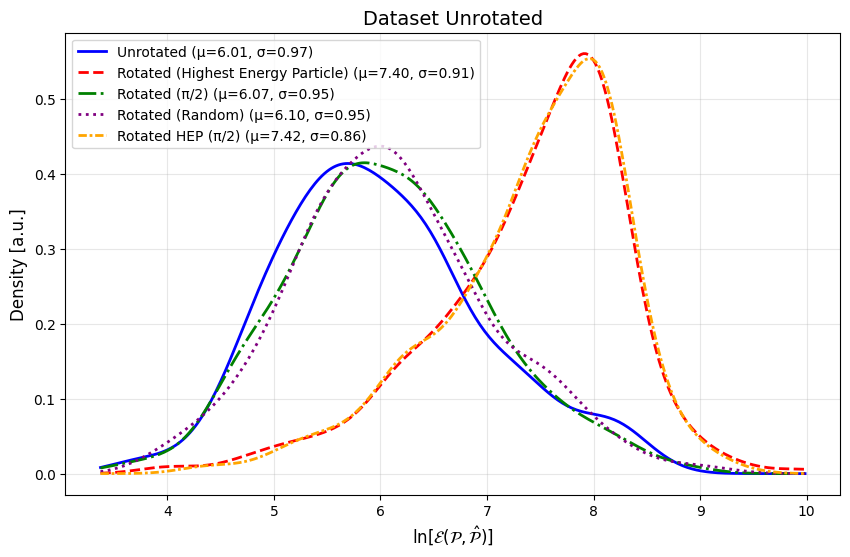

In [12]:
plot_emd_for_five_models("Dataset Unrotated", log_emd_val_unrotated, model, model_rotated, model_rotated_halfpi, model_rotated_rand, model_rotated_hep_halfpi)

Unrotated              — Mean: 5.9872, Std: 0.9856
Rotated (Highest Energy Particle) — Mean: 7.3967, Std: 0.8769
Rotated (π/2)          — Mean: 6.0233, Std: 0.9223
Rotated (Random)       — Mean: 6.0646, Std: 0.9671
Rotated HEP (π/2)      — Mean: 7.4394, Std: 0.8311


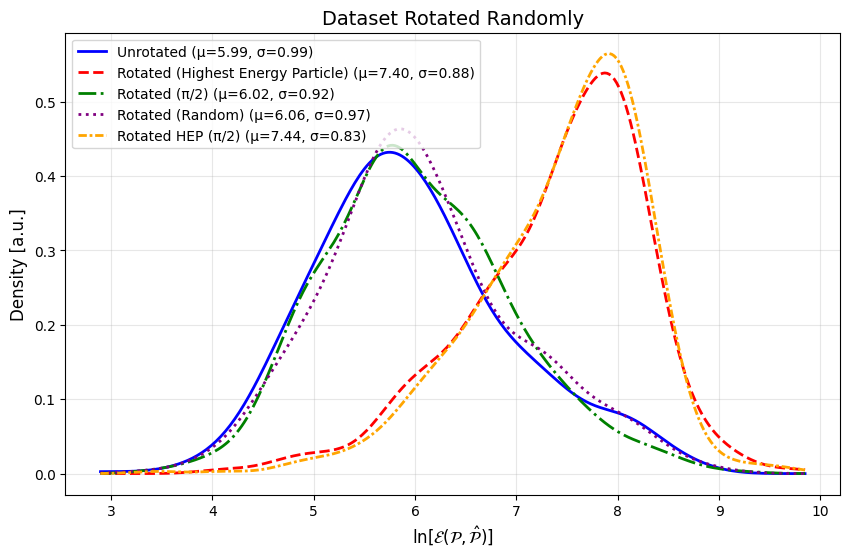

In [13]:

plot_emd_for_five_models("Dataset Rotated Randomly",log_emd_val_rotated_rand, model, model_rotated, model_rotated_halfpi, model_rotated_rand, model_rotated_hep_halfpi)


Unrotated              — Mean: 6.0218, Std: 0.9685
Rotated (Highest Energy Particle) — Mean: 7.4575, Std: 0.8492
Rotated (π/2)          — Mean: 6.0662, Std: 0.9704
Rotated (Random)       — Mean: 6.1044, Std: 0.9466
Rotated HEP (π/2)      — Mean: 7.4924, Std: 0.7530


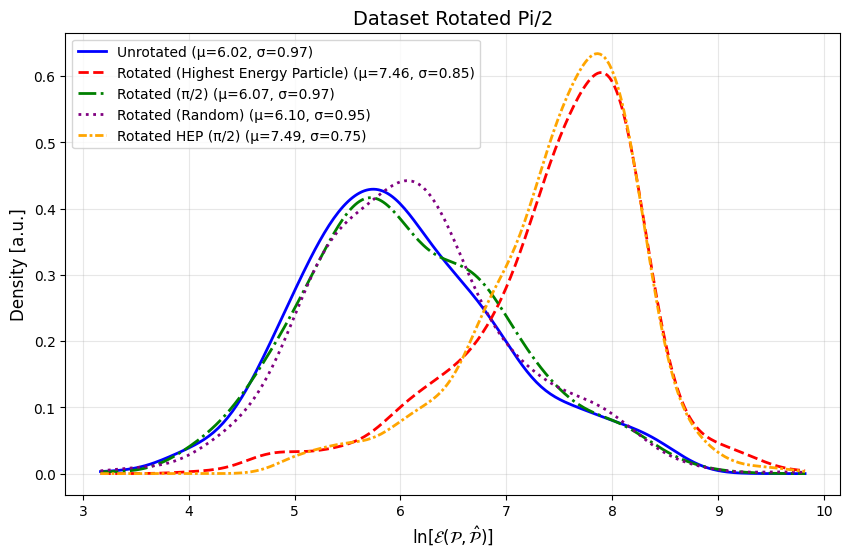

In [17]:
plot_emd_for_five_models("Dataset Rotated Pi/2", log_emd_val_rotated_halfpi, model, model_rotated, model_rotated_halfpi, model_rotated_rand, model_rotated_hep_halfpi)                 

Unrotated              — Mean: 5.4279, Std: 1.0027
Rotated (Highest Energy Particle) — Mean: 5.3701, Std: 1.0656
Rotated (π/2)          — Mean: 5.4009, Std: 0.9709
Rotated (Random)       — Mean: 5.4353, Std: 0.9590
Rotated HEP (π/2)      — Mean: 5.4572, Std: 0.8897


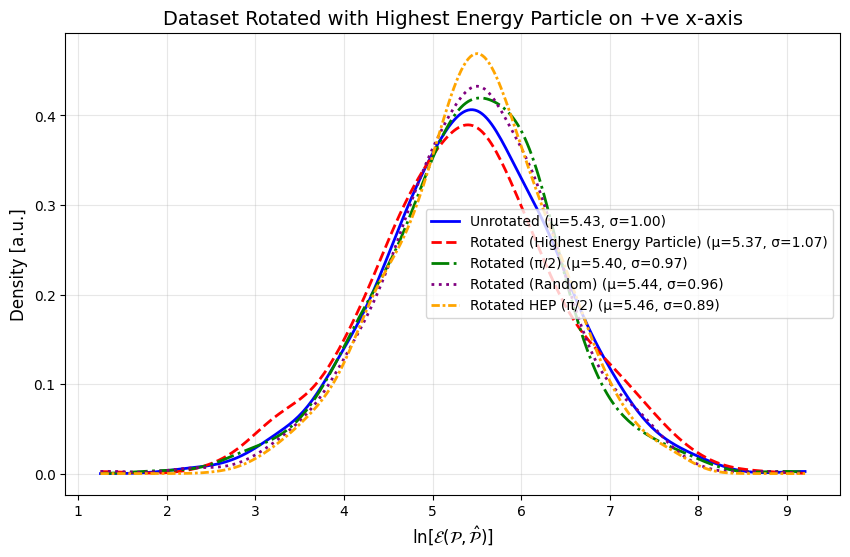

In [18]:
plot_emd_for_five_models("Dataset Rotated with Highest Energy Particle on +ve x-axis",log_emd_val_rotated, model, model_rotated, model_rotated_halfpi, model_rotated_rand, model_rotated_hep_halfpi)


Unrotated              — Mean: 5.6699, Std: 0.9939
Rotated (Highest Energy Particle) — Mean: 5.3710, Std: 1.0052
Rotated (π/2)          — Mean: 5.6764, Std: 0.9058
Rotated (Random)       — Mean: 5.7182, Std: 0.9028
Rotated HEP (π/2)      — Mean: 5.1925, Std: 0.9401


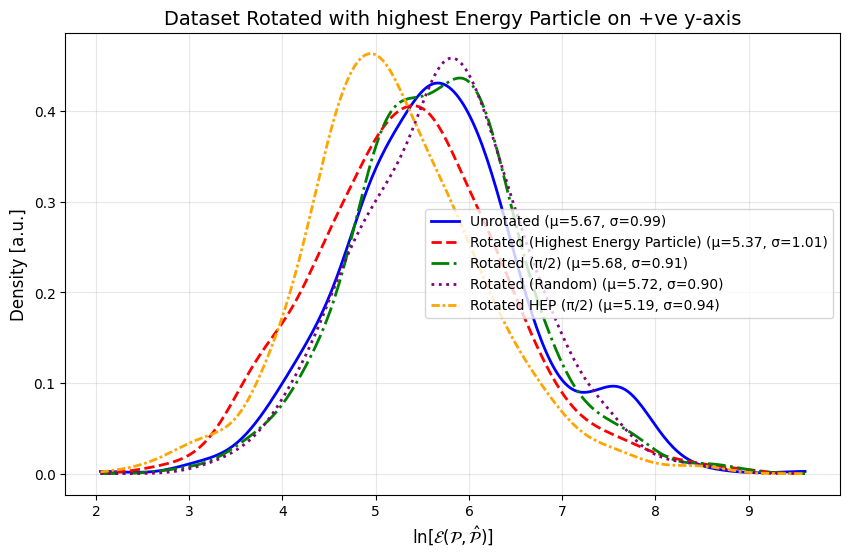

In [20]:
plot_emd_for_five_models("Dataset Rotated with highest Energy Particle on +ve y-axis", log_emd_val_rotated_hep_halfpi, model, model_rotated, model_rotated_halfpi, model_rotated_rand, model_rotated_hep_halfpi)


Unrotated              — Mean: 6.0218, Std: 0.9685
Rotated (Highest Energy Particle) — Mean: 7.4575, Std: 0.8492
Rotated (π/2)          — Mean: 6.0662, Std: 0.9704
Rotated (Random)       — Mean: 6.1044, Std: 0.9466
Rotated HEP (π/2)      — Mean: 7.4924, Std: 0.7530


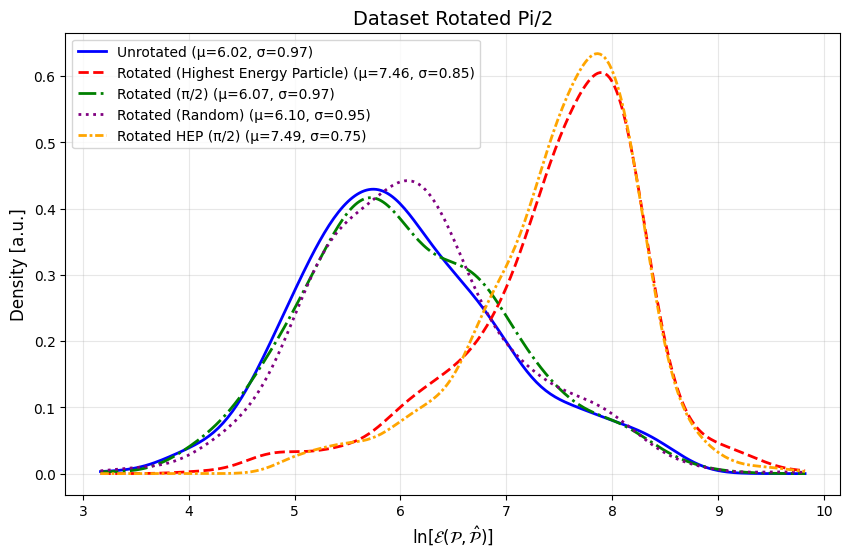

In [21]:
plot_emd_for_five_models("Dataset Rotated Pi/2", log_emd_val_rotated_halfpi, model, model_rotated, model_rotated_halfpi, model_rotated_rand, model_rotated_hep_halfpi)
